# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Becca Hobson

**Date:** 9/9/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


[Q1, page 1](https://drive.google.com/file/d/1q4pELHpJ85ZYoxrS3jPakiGhCebBPigD/view)
[Q2, page 2](https://drive.google.com/file/d/1sZKHYTdZMKFpi8xlufioHytOxUz5VjGa/view)


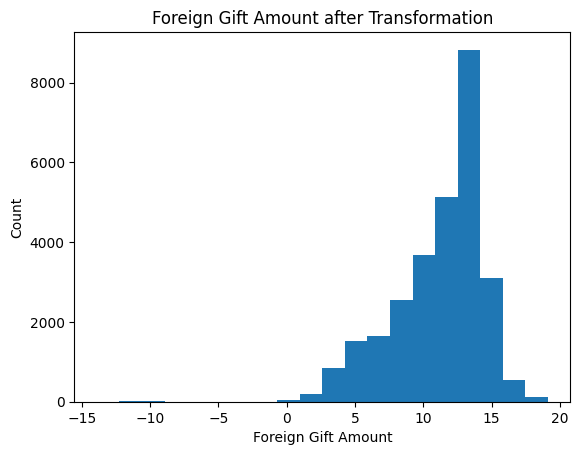

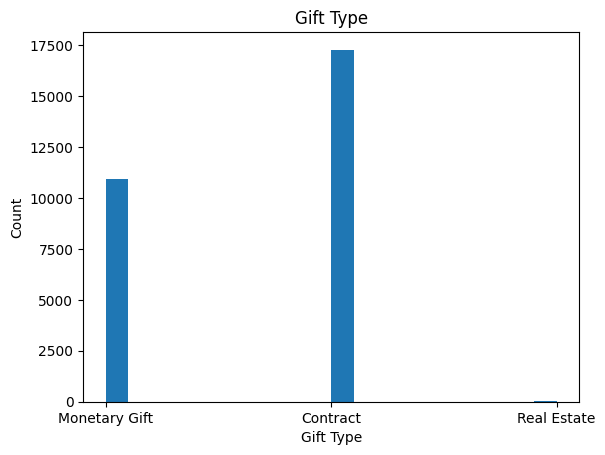


Proportion of Monetary Gifts as a %: 38.75
Proportion of Contract Gifts as a %: 61.21
Proportion of Real Estate Gifts as a %: 0.04


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


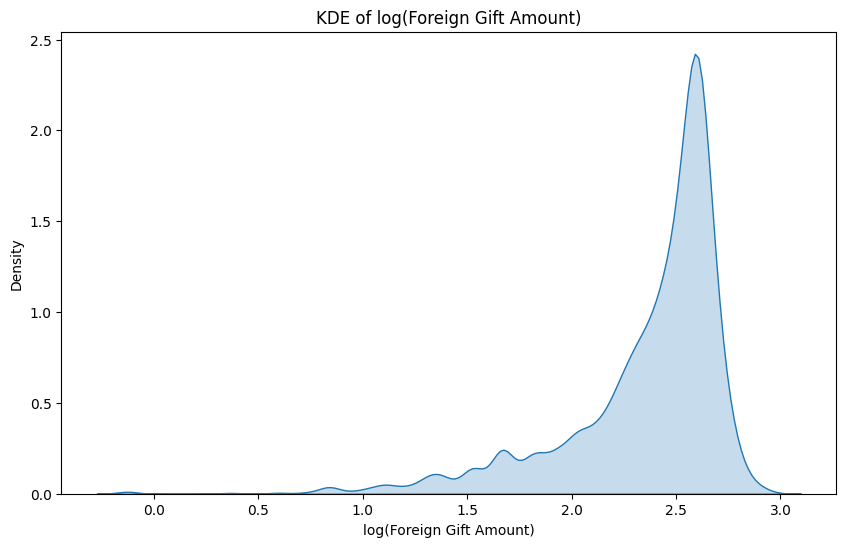

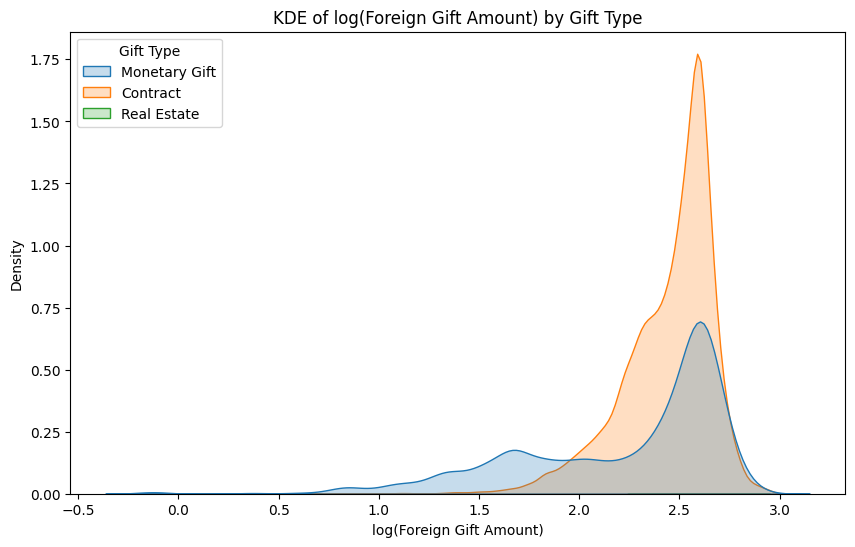


Top 15 Countries by Number of Gifts: Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

Top 15 Countries by Total Dollar Amount:
 Country of Giftor
ENGLAND                 36809.94
CHINA                   28225.51
CANADA                  21333.70
JAPAN                   20751.40
SAUDI ARABIA            19347.06
SWITZERLAND             19071.61
FRANCE                  15599.09
GERMANY                 14738.06
HONG KONG               12459.74
QATAR                    9321.28
SOUTH KOREA              8399.69
THE NETHERLANDS          5859.72
KOREA                    5493.03
INDIA                    5456.38
UNITED ARAB EMIRATES     4733.28
Name: Foreign G

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fgdf = pd.read_csv('/content/ForeignGifts_edu.csv')

fgdf.head(20)
fgdf.sample(20) #looking at data

#Create Histogram for Foreign Gift Amount
fgdf['Foreign Gift Amount'] = np.arcsinh(fgdf['Foreign Gift Amount']) #arcsin trnasformation to adjust scale
fgdf['Foreign Gift Amount'].hist(bins=20, grid=False)
plt.title('Foreign Gift Amount after Transformation')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Count')
plt.show()

#Create Histogram for Gift Type
fgdf['Gift Type'].hist(bins=20, grid=False)
plt.title('Gift Type')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.show()

#Proportion of Gift Types
monetary_proportion = ((fgdf['Gift Type'] == 'Monetary Gift').sum() / len(fgdf))
print('\nProportion of Monetary Gifts as a %:', round(monetary_proportion * 100, 2)) #round to 2 decimal places
contract_proportion = ((fgdf['Gift Type'] == 'Contract').sum() / len(fgdf))
print('Proportion of Contract Gifts as a %:', round(contract_proportion * 100, 2)) #round to 2 decimal places
realestate_proportion = ((fgdf['Gift Type'] == 'Real Estate').sum() / len(fgdf))
print('Proportion of Real Estate Gifts as a %:', round(realestate_proportion * 100, 2)) #round to 2 decimal places

#KDE Displays
fgdf['log_amount'] = np.log(fgdf['Foreign Gift Amount'])
plt.figure(figsize=(10,6))
sns.kdeplot(data=fgdf, x='log_amount', fill=True)
plt.title('KDE of log(Foreign Gift Amount)')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(10,6))
sns.kdeplot(data=fgdf, x='log_amount', hue='Gift Type', fill=True) #conditional on gift type
plt.title('KDE of log(Foreign Gift Amount) by Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

#Top 15 Giftors by Number of Gifts & Dollar Amount
top15_count = (fgdf.groupby(['Country of Giftor']).size().sort_values(ascending=False).head(15)) #display top 15 countries
print('\nTop 15 Countries by Number of Gifts:', (top15_count))
top15_amount = (fgdf.groupby(['Country of Giftor'])['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)) #display top 15 giftors
print('\nTop 15 Countries by Total Dollar Amount:\n', (top15_amount.round(2))) #round to 2 decimal places

#Top Giftors Total
top_giftors = (fgdf.groupby(['Giftor Name'])['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)) #display top 15 giftors
print('\nTop giftors by total amount given:\n', (top_giftors.round(2))) #round to 2 decimal places





## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]